# 06 · Experiments and the final model (Step 7)

**Goal:** three experiments, then the final model that every later step uses.

- **A. Fix:** the "still running previous loans" features were empty in Steps 5 and 6. Fix them and measure LightGBM v1 again.
- **B. Class imbalance:** only 8% of loans default. Do class weights, undersampling or SMOTE help?
- **C. Tuning:** grid search vs random search vs Bayesian optimisation (Optuna), with the same budget. The best settings become the **final model**, saved in `models/`.

**Before running:** rebuild the features with `make features` (the setup cell checks this).

**Time:** about 1 to 1.5 hours; the tuning (Part C) is most of it.
**You can stop and re-run at any time:** model predictions are saved in `data/processed/oof/` and
every tuning trial in `data/processed/tuning/`, so a re-run continues where it stopped.

**Saved results:**

- `reports/results_step7_imbalance.csv`, `reports/results_step7_tuning.csv`
- `reports/figures/fig16_imbalance_calibration.png`, `reports/figures/fig17_tuning_curves.png`
- `models/lightgbm_final.joblib` (plus `.txt` and `.json`)
- MLflow (`make mlflow`)

In [1]:
%load_ext autoreload
%autoreload 2

import dataclasses

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import calibration_curve

from creditrisk.config import PROJECT_ROOT, get_path, set_seed
from creditrisk.data.split import load_splits
from creditrisk.evaluation.bootstrap import paired_bootstrap
from creditrisk.evaluation.cv import load_result, results_table, run_or_load
from creditrisk.features.build import load_features
from creditrisk.models import baselines, tune
from creditrisk.models.baselines import default_threads
from creditrisk.models.data import column_groups, get_xy
from creditrisk.models.final import save_final_model
from creditrisk.models.imbalance import imbalance_models

SEED = set_seed()
FIG = get_path("figures")
REPORTS = PROJECT_ROOT / "reports"
TUNE_DIR = get_path("processed") / "tuning"
facts = {}

features = load_features()
splits = load_splits()
X, y, folds, ids = get_xy(features, splits, "train")
yv = np.asarray(y)
groups = column_groups(X)
assert X["PREV_RUNNING_CREDIT_TOTAL"].notna().any(), (
    "PREV_RUNNING_CREDIT_TOTAL is still empty: run `make features`, then restart the kernel.")
print(f"train split: {X.shape[0]:,} rows x {X.shape[1]} features | threads: {default_threads()}")

train split: 184,503 rows x 240 features | threads: 8


## A. Fix the "still running" previous loans

**What was wrong:** in `previous_application`, a loan that has not ended yet has the code 365243
in its end-date columns (the data has no real future dates). Step 5 turned 365243 into "missing"
first, and only then looked for end dates in the future, so it never found a running loan:
`PREV_RUNNING_COUNT` was always 0 and `PREV_RUNNING_CREDIT_TOTAL` was always empty.
Now "still running" is read **before** 365243 is removed.

Steps 5 and 6 used the old features. From here on, every model uses the fixed ones.

In [2]:
running = (X["PREV_RUNNING_COUNT"].fillna(0) > 0).to_numpy()
rate_running, rate_not = yv[running].mean(), yv[~running].mean()
useless = [c for c in X.columns if X[c].nunique(dropna=True) <= 1]
print(f"applicants with at least one running previous loan: {running.mean():.1%}")
print(f"default rate: with a running loan {rate_running:.2%} | without {rate_not:.2%}")
print("empty or constant columns:", useless or "none")
facts["running_loan_share"] = round(float(running.mean()), 4)
facts["default_running_vs_not"] = (round(float(rate_running), 4), round(float(rate_not), 4))
facts["empty_or_constant_columns"] = useless

applicants with at least one running previous loan: 49.4%
default rate: with a running loan 8.37% | without 7.79%
empty or constant columns: none


In [3]:
v1 = run_or_load(lambda: baselines.lightgbm(seed=SEED), X, y, folds, "step7_lightgbm_v1_fixed",
                 ids=ids, step=7, verbose=True)
v1.name = "lightgbm_v1 (fixed features)"
try:
    v1_old = load_result("step5_ablation_5", ids=ids, display_name="lightgbm_v1 (old features)")
    gain = paired_bootstrap(yv, v1.oof, v1_old.oof)
    display(results_table([v1_old, v1]))
    print(f"fixed - old: {gain['difference']:+.4f} "
          f"(95% CI {gain['low']:+.4f} to {gain['high']:+.4f}), significant: {gain['significant']}")
    facts["v1_old_vs_fixed"] = (round(v1_old.summary["roc_auc"], 4), round(v1.summary["roc_auc"], 4))
    facts["fix_gain"] = (round(gain["difference"], 4), gain["significant"])
except FileNotFoundError:
    display(results_table([v1]))
    print("Step 5 predictions not found, so no before/after comparison.")
    facts["v1_fixed"] = round(v1.summary["roc_auc"], 4)

  step7_lightgbm_v1_fixed: fold 1 done, ROC-AUC 0.7889 (15s so far)
  step7_lightgbm_v1_fixed: fold 2 done, ROC-AUC 0.7907 (31s so far)
  step7_lightgbm_v1_fixed: fold 3 done, ROC-AUC 0.7794 (44s so far)
  step7_lightgbm_v1_fixed: fold 4 done, ROC-AUC 0.7842 (58s so far)
  step7_lightgbm_v1_fixed: fold 5 done, ROC-AUC 0.7916 (72s so far)


,ROC-AUC,95% CI,fold mean ± std,PR-AUC,KS,Brier,ECE,seconds
model,,,,,,,,
lightgbm_v1 (fixed features),0.787,0.7836 to 0.7903,0.7870 ± 0.0051,0.2734,0.4316,0.0662,0.0040,72.3
lightgbm_v1 (old features),0.786,0.7826 to 0.7895,0.7860 ± 0.0045,0.2735,0.4280,0.0662,0.0042,NaN


fixed - old: +0.0009 (95% CI -0.0001 to +0.0020), significant: False


## B. Class imbalance

Only about 1 in 12 loans defaults. Three common "fixes", all applied **only to the training
fold** (the held-out fold is never changed):

- **Class weights:** each defaulter counts about 11 times as much in the loss.
- **Undersampling:** randomly drop non-defaulters until there is 1 defaulter for every 2 others.
- **SMOTE:** create synthetic defaulters between real neighbouring defaulters, up to the same 1:2 ratio.

SMOTE needs complete numbers, so it needs extra preprocessing (fill gaps, scale, code the text
columns). That preprocessing alone could change the score, so it gets its own **control**,
`imputed_no_smote`: the same preprocessing, without SMOTE. The real SMOTE effect is
smote vs that control. "none" is LightGBM v1 from Part A.

**What to watch:** ROC-AUC only checks the *ranking* of applicants. These methods mainly change
the *probabilities*, and Step 10 sets the approval threshold from those probabilities, so the
calibration columns (Brier, ECE, average predicted probability) matter as much as ROC-AUC.

In [4]:
imbalance = {"none": dataclasses.replace(v1, name="none")}
for name, make_model in imbalance_models(groups, seed=SEED).items():
    if name == "none":
        continue  # the same model as LightGBM v1 above, already trained
    r = run_or_load(make_model, X, y, folds, f"step7_imb_{name}", ids=ids, step=7, verbose=True)
    r.name = name
    imbalance[name] = r

vs_none = {m: paired_bootstrap(yv, r.oof, imbalance["none"].oof)
           for m, r in imbalance.items() if m != "none"}
table = results_table(imbalance.values())
table["vs none"] = ["—" if m == "none" else
                    f"{vs_none[m]['difference']:+.4f}" + ("*" if vs_none[m]["significant"] else "")
                    for m in table.index]
table["avg predicted p"] = [round(float(imbalance[m].oof.mean()), 4) for m in table.index]
table["actual default rate"] = round(float(yv.mean()), 4)
table.to_csv(REPORTS / "results_step7_imbalance.csv")
display(table[["ROC-AUC", "95% CI", "vs none", "PR-AUC", "Brier", "ECE", "avg predicted p",
               "actual default rate"]])
print("* = significant change in ROC-AUC vs none (paired bootstrap)")

smote_effect = paired_bootstrap(yv, imbalance["smote"].oof, imbalance["imputed_no_smote"].oof)
print(f"SMOTE effect (smote - imputed_no_smote): {smote_effect['difference']:+.4f} "
      f"(95% CI {smote_effect['low']:+.4f} to {smote_effect['high']:+.4f}), "
      f"significant: {smote_effect['significant']}")

facts["imbalance_auc"] = {m: round(r.summary["roc_auc"], 4) for m, r in imbalance.items()}
facts["imbalance_vs_none"] = {m: (round(c["difference"], 4), c["significant"])
                              for m, c in vs_none.items()}
facts["imbalance_brier"] = {m: round(r.summary["brier"], 4) for m, r in imbalance.items()}
facts["imbalance_ece"] = {m: round(r.summary["ece"], 4) for m, r in imbalance.items()}
facts["imbalance_avg_p"] = {m: round(float(r.oof.mean()), 4) for m, r in imbalance.items()}
facts["smote_effect"] = (round(smote_effect["difference"], 4), smote_effect["significant"])

  step7_imb_class_weights: fold 1 done, ROC-AUC 0.7891 (14s so far)
  step7_imb_class_weights: fold 2 done, ROC-AUC 0.7894 (29s so far)
  step7_imb_class_weights: fold 3 done, ROC-AUC 0.7771 (43s so far)
  step7_imb_class_weights: fold 4 done, ROC-AUC 0.7819 (57s so far)
  step7_imb_class_weights: fold 5 done, ROC-AUC 0.7888 (72s so far)
  step7_imb_undersampling: fold 1 done, ROC-AUC 0.7860 (6s so far)
  step7_imb_undersampling: fold 2 done, ROC-AUC 0.7873 (11s so far)
  step7_imb_undersampling: fold 3 done, ROC-AUC 0.7745 (16s so far)
  step7_imb_undersampling: fold 4 done, ROC-AUC 0.7817 (21s so far)
  step7_imb_undersampling: fold 5 done, ROC-AUC 0.7862 (26s so far)
  step7_imb_imputed_no_smote: fold 1 done, ROC-AUC 0.7897 (16s so far)
  step7_imb_imputed_no_smote: fold 2 done, ROC-AUC 0.7894 (32s so far)
  step7_imb_imputed_no_smote: fold 3 done, ROC-AUC 0.7760 (45s so far)
  step7_imb_imputed_no_smote: fold 4 done, ROC-AUC 0.7830 (61s so far)
  step7_imb_imputed_no_smote: fold 5 

,ROC-AUC,95% CI,vs none,PR-AUC,Brier,ECE,avg predicted p,actual default rate
model,,,,,,,,
none,0.7870,0.7836 to 0.7903,—,0.2734,0.0662,0.0040,0.0789,0.0807
imputed_no_smote,0.7858,0.7825 to 0.7892,-0.0012,0.2713,0.0663,0.0037,0.0791,0.0807
class_weights,0.7852,0.7820 to 0.7884,-0.0017*,0.2732,0.1534,0.2540,0.3347,0.0807
undersampling,0.7831,0.7797 to 0.7866,-0.0038*,0.2680,0.1179,0.1890,0.2697,0.0807
smote,0.7831,0.7795 to 0.7866,-0.0039*,0.2685,0.0665,0.0033,0.0837,0.0807


* = significant change in ROC-AUC vs none (paired bootstrap)
SMOTE effect (smote - imputed_no_smote): -0.0027 (95% CI -0.0039 to -0.0014), significant: True


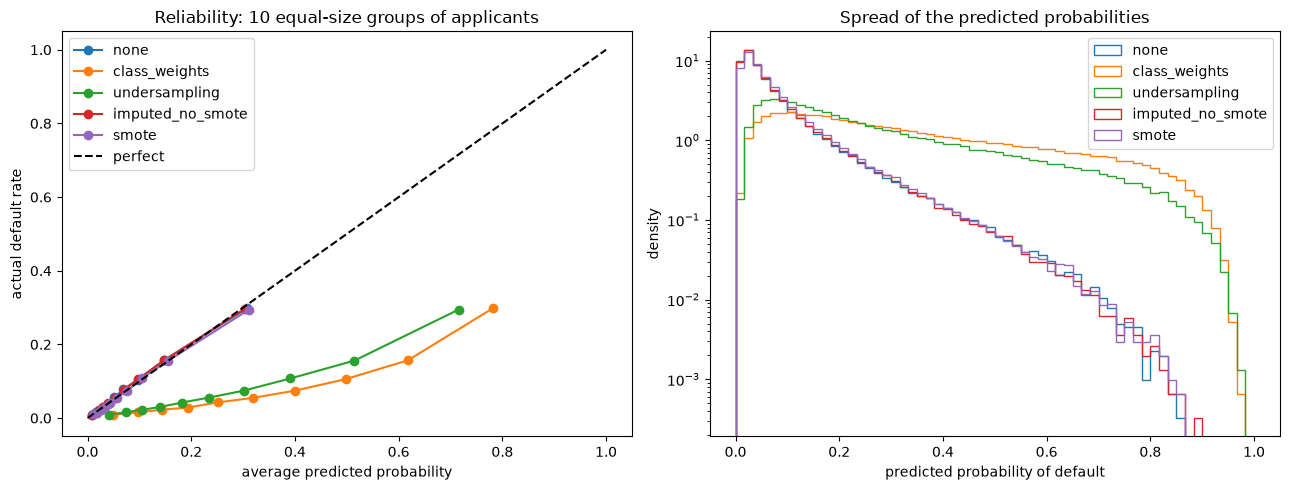

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
for name, r in imbalance.items():
    actual, predicted = calibration_curve(yv, r.oof, n_bins=10, strategy="quantile")
    ax1.plot(predicted, actual, marker="o", label=name)
    ax2.hist(r.oof, bins=60, range=(0, 1), histtype="step", density=True, label=name)
ax1.plot([0, 1], [0, 1], "k--", label="perfect")
ax1.set(xlabel="average predicted probability", ylabel="actual default rate",
        title="Reliability: 10 equal-size groups of applicants")
ax2.set(xlabel="predicted probability of default", ylabel="density", yscale="log",
        title="Spread of the predicted probabilities")
ax1.legend()
ax2.legend()
fig.tight_layout()
fig.savefig(FIG / "fig16_imbalance_calibration.png", dpi=150)
plt.show()

## C. Tuning: grid vs random vs Bayesian optimisation (Optuna)

All three methods get the **same budget: 27 LightGBM fits**, and every fit is checked the same
way: train on folds 2–5, keep adding trees until the ROC-AUC on fold 1 has not improved for 100
rounds (**early stopping**), and record that ROC-AUC.

- **Grid search:** every combination of 3 learning rates × 3 leaf counts × 3 minimum leaf sizes. The other settings stay at the v1 values.
- **Random search:** 27 random settings from wider ranges, for all six settings.
- **Bayesian optimisation (Optuna TPE):** the first 8 tries are random. After that, each new try is chosen using all earlier results, aiming at the most promising area.

The v1 settings are scored the same way first, as the reference line.

Each trial prints one line and is saved as soon as it finishes. You can stop at any time and run
the cell again later: finished trials are not repeated.

**Honest note:** fold 1 is used to choose the settings, so the tuned model's 5-fold score is a
little optimistic. Also, fold 1 has only about 37,000 rows, so small differences between trials
can be noise. The final, unbiased number comes from the locked test set in Step 15.

In [6]:
BUDGET = 27


def score(params):
    return tune.holdout_score(params, X, y, folds, holdout=1, seed=SEED)


reference = tune.run_search("v1_settings", [{}], score, TUNE_DIR, verbose=False)
print(f"v1 settings, same check: ROC-AUC {reference['auc'][0]:.4f} "
      f"with {reference['trees'][0]} trees\n")
grid = tune.run_search("grid", tune.grid_candidates(), score, TUNE_DIR)
rand = tune.run_search("random", tune.random_candidates(BUDGET, seed=SEED), score, TUNE_DIR)
tpe = tune.run_optuna(BUDGET, score, TUNE_DIR, seed=SEED)

v1 settings, same check: ROC-AUC 0.7894 with 371 trees

  grid 1/27: ROC-AUC 0.7920 with 1696 trees (44s), best so far 0.7920
  grid 2/27: ROC-AUC 0.7924 with 1903 trees (49s), best so far 0.7924
  grid 3/27: ROC-AUC 0.7924 with 1242 trees (34s), best so far 0.7924
  grid 4/27: ROC-AUC 0.7912 with 1224 trees (40s), best so far 0.7924
  grid 5/27: ROC-AUC 0.7915 with 857 trees (30s), best so far 0.7924
  grid 6/27: ROC-AUC 0.7922 with 916 trees (33s), best so far 0.7924
  grid 7/27: ROC-AUC 0.7897 with 721 trees (35s), best so far 0.7924
  grid 8/27: ROC-AUC 0.7901 with 592 trees (30s), best so far 0.7924
  grid 9/27: ROC-AUC 0.7911 with 707 trees (36s), best so far 0.7924
  grid 10/27: ROC-AUC 0.7899 with 671 trees (20s), best so far 0.7924
  grid 11/27: ROC-AUC 0.7910 with 614 trees (18s), best so far 0.7924
  grid 12/27: ROC-AUC 0.7927 with 613 trees (19s), best so far 0.7927
  grid 13/27: ROC-AUC 0.7865 with 274 trees (12s), best so far 0.7927
  grid 14/27: ROC-AUC 0.7884 with 296 t

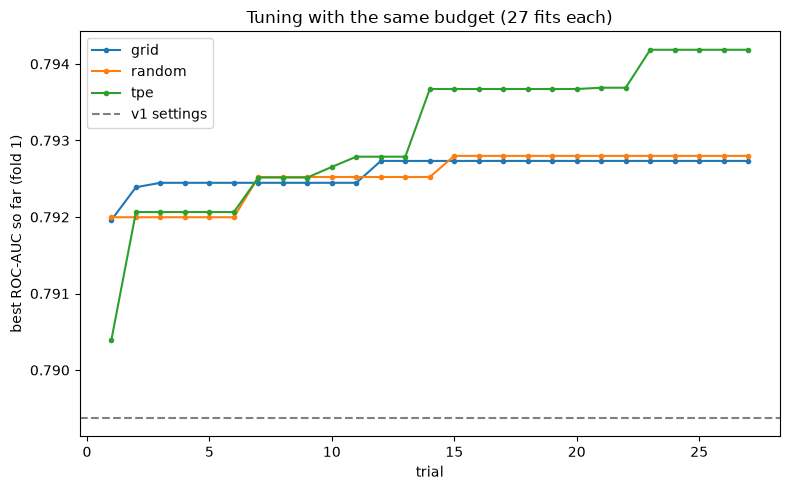

,best ROC-AUC,found at trial,trees,minutes,best settings
method,,,,,
grid,0.7927,12,613,9.2,"{'learning_rate': 0.05, 'num_leaves': 16, 'min..."
random,0.7928,15,1397,6.2,"{'learning_rate': 0.020744599445731385, 'num_l..."
tpe,0.7942,23,1701,12.1,"{'learning_rate': 0.021891496669170604, 'num_l..."


In [7]:
searches = {"grid": grid, "random": rand, "tpe": tpe}
fig, ax = plt.subplots(figsize=(8, 5))
for method, trials in searches.items():
    ax.plot(trials["trial"] + 1, trials["best_so_far"], marker=".", label=method)
ax.axhline(reference["auc"][0], color="grey", linestyle="--", label="v1 settings")
ax.set(xlabel="trial", ylabel="best ROC-AUC so far (fold 1)",
       title=f"Tuning with the same budget ({BUDGET} fits each)")
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "fig17_tuning_curves.png", dpi=150)
plt.show()

rows = []
for method, trials in searches.items():
    top = trials["auc"].idxmax()
    rows.append({"method": method, "best ROC-AUC": round(trials["auc"].max(), 4),
                 "found at trial": int(top) + 1, "trees": int(trials.loc[top, "trees"]),
                 "minutes": round(trials["seconds"].sum() / 60, 1),
                 "best settings": trials.loc[top, "params"]})
search_summary = pd.DataFrame(rows).set_index("method")
display(search_summary)
pd.concat([reference, grid, rand, tpe], ignore_index=True).to_csv(
    REPORTS / "results_step7_tuning.csv", index=False)

facts["tuning_v1_reference"] = round(float(reference["auc"][0]), 4)
facts["tuning_best"] = search_summary["best ROC-AUC"].to_dict()
facts["tuning_found_at_trial"] = search_summary["found at trial"].to_dict()
facts["tuning_minutes"] = search_summary["minutes"].to_dict()

## The final model

Take the best trial over all three searches and check it properly: full 5-fold CV with the
number of trees it needed in the search, compared with LightGBM v1 (paired bootstrap).
If it does not beat v1, the v1 settings stay.

Then the chosen model is trained once on the **whole train split** and saved. Every later step
(calibration, conformal, explanations, fairness, the app) uses this saved model.

In [8]:
best = tune.best_trial(grid, rand, tpe)
best_params, best_trees = dict(best["params"]), int(best["trees"])
print(f"best trial: {best['method']} #{best['trial'] + 1}, ROC-AUC on fold 1 {best['auc']:.4f}, "
      f"{best_trees} trees")
print("settings:", best_params)

tuned = run_or_load(lambda: tune.tuned_lightgbm(best_params, best_trees, seed=SEED), X, y, folds,
                    f"step7_lightgbm_tuned_{best['method']}{best['trial'] + 1}", ids=ids, step=7,
                    verbose=True)
tuned.name = "lightgbm_tuned"
vs_v1 = paired_bootstrap(yv, tuned.oof, v1.oof)
display(results_table([tuned, v1]))
print(f"tuned - v1: {vs_v1['difference']:+.4f} "
      f"(95% CI {vs_v1['low']:+.4f} to {vs_v1['high']:+.4f}), significant: {vs_v1['significant']}")

facts["best_trial"] = (best["method"], int(best["trial"]) + 1, round(float(best["auc"]), 4))
facts["best_settings"] = {k: (round(v, 4) if isinstance(v, float) else v)
                          for k, v in best_params.items()}
facts["tuned_cv"] = (round(tuned.summary["roc_auc"], 4),
                     round(tuned.summary["roc_auc_low"], 4), round(tuned.summary["roc_auc_high"], 4))
facts["v1_fixed_cv"] = round(v1.summary["roc_auc"], 4)
facts["tuned_vs_v1"] = (round(vs_v1["difference"], 4), vs_v1["significant"])

best trial: tpe #23, ROC-AUC on fold 1 0.7942, 1701 trees
settings: {'learning_rate': 0.021891496669170604, 'num_leaves': 17, 'min_child_samples': 426, 'subsample': 0.9508052134172866, 'colsample_bytree': 0.27184224534712853, 'reg_lambda': 0.45715883411989156}
  step7_lightgbm_tuned_tpe23: fold 1 done, ROC-AUC 0.7942 (33s so far)
  step7_lightgbm_tuned_tpe23: fold 2 done, ROC-AUC 0.7923 (66s so far)
  step7_lightgbm_tuned_tpe23: fold 3 done, ROC-AUC 0.7818 (98s so far)
  step7_lightgbm_tuned_tpe23: fold 4 done, ROC-AUC 0.7876 (131s so far)
  step7_lightgbm_tuned_tpe23: fold 5 done, ROC-AUC 0.7935 (164s so far)


,ROC-AUC,95% CI,fold mean ± std,PR-AUC,KS,Brier,ECE,seconds
model,,,,,,,,
lightgbm_tuned,0.7899,0.7865 to 0.7930,0.7899 ± 0.0052,0.2791,0.4386,0.0659,0.002,163.5
lightgbm_v1 (fixed features),0.7870,0.7836 to 0.7903,0.7870 ± 0.0051,0.2734,0.4316,0.0662,0.004,72.3


tuned - v1: +0.0029 (95% CI +0.0020 to +0.0039), significant: True


In [9]:
if tuned.summary["roc_auc"] > v1.summary["roc_auc"]:
    chosen, final_params = "tuned", best_params
    final_trees = int(round(best_trees * 1.1))  # 25% more rows than in the search: a few more trees
    cv = tuned.summary
else:
    chosen, final_params, final_trees, cv = "v1 settings (tuning did not beat them)", {}, 500, v1.summary

final_model = tune.tuned_lightgbm(final_params, final_trees, seed=SEED).fit(X, y)
info = {
    "step": 7,
    "chosen": chosen,
    "params": final_params,
    "n_estimators": final_trees,
    "trained_on": f"train split, {len(X):,} rows",
    "cv_roc_auc": round(cv["roc_auc"], 4),
    "cv_roc_auc_95ci": [round(cv["roc_auc_low"], 4), round(cv["roc_auc_high"], 4)],
    "seed": SEED,
}
folder = save_final_model(final_model, X.columns, info)
print(f"final model: {chosen}, {final_trees} trees, saved in {folder}")
facts["final_model"] = (chosen, final_trees, round(cv["roc_auc"], 4))

final model: tuned, 1871 trees, saved in /home/amartya/Desktop/prmlproject/models


## Key facts
Send these to Claude to get the filled-in Findings.

In [10]:
for key, value in facts.items():
    print(f"{key:<28} {value}")

running_loan_share           0.4943
default_running_vs_not       (0.0837, 0.0779)
empty_or_constant_columns    []
v1_old_vs_fixed              (0.786, 0.787)
fix_gain                     (0.0009, False)
imbalance_auc                {'none': 0.787, 'class_weights': 0.7852, 'undersampling': 0.7831, 'imputed_no_smote': 0.7858, 'smote': 0.7831}
imbalance_vs_none            {'class_weights': (-0.0017, True), 'undersampling': (-0.0038, True), 'imputed_no_smote': (-0.0012, False), 'smote': (-0.0039, True)}
imbalance_brier              {'none': 0.0662, 'class_weights': 0.1534, 'undersampling': 0.1179, 'imputed_no_smote': 0.0663, 'smote': 0.0665}
imbalance_ece                {'none': 0.004, 'class_weights': 0.254, 'undersampling': 0.189, 'imputed_no_smote': 0.0037, 'smote': 0.0033}
imbalance_avg_p              {'none': 0.0789, 'class_weights': 0.3347, 'undersampling': 0.2697, 'imputed_no_smote': 0.0791, 'smote': 0.0837}
smote_effect                 (-0.0027, True)
tuning_v1_reference          0

## Findings

- **A. Fix:** 49.4% of applicants have at least one previous loan that is still running. Their default rate is 8.37% vs 7.79% without one. No empty or constant columns remain. LightGBM v1 went from 0.786 (old features) to 0.787 (fixed), a change of +0.0009 (not significant). The fix corrects the data but adds little new signal, probably because other previous-loan features already carry most of this information.
- **B. Imbalance (ROC-AUC):** none 0.7870, class weights 0.7852, undersampling 0.7831, SMOTE 0.7831 (control without SMOTE 0.7858). All three "fixes" are significantly *worse* than doing nothing (−0.0017, −0.0038, −0.0039). The control's −0.0012 is not significant, but SMOTE vs its control is (−0.0027).
- **B. Probabilities:** with no fix, the average predicted probability is 0.079 vs an actual default rate of 0.081 (ECE 0.004, Brier 0.066). Class weights push it to 0.335 (ECE 0.254, Brier 0.153) and undersampling to 0.270 (ECE 0.189, Brier 0.118), so their probabilities can no longer be used for money decisions.
- **B. The SMOTE surprise:** SMOTE trained on 1 defaulter for every 2 others, like undersampling, yet its average probability stayed at 0.084 (ECE 0.003). The reason: every synthetic row has at least one in-between value that no real applicant has (for example 1.4 children), so the trees learn to spot the synthetic rows. On this data, 100% of synthetic rows have such a value (checked in the 73 columns with 30 or fewer distinct values), and a model separates synthetic from real defaulters perfectly (ROC-AUC 1.000). The trees give synthetic rows a high probability and real applicants roughly their real rate. So SMOTE mostly taught the model to recognise fake applicants, and the effort spent on that made the ranking of real applicants slightly worse.
- **B. Decision:** no reweighting or resampling. Train on the natural 8% default rate. The probabilities are already well calibrated, and Step 10 checks calibration in detail.
- **C. Tuning (best ROC-AUC on fold 1 after 27 fits):** grid 0.7927, random 0.7928, Optuna TPE 0.7942; v1 settings 0.7894. The best was found at trial 12 (grid), 15 (random) and 23 (TPE), in 9.2, 6.2 and 12.1 minutes. All three beat the v1 settings. TPE found the best trial, but the gaps between the methods (at most 0.0015) are smaller than the noise on one fold, so this one run does not prove that TPE is better in general.
- **C. Best settings (TPE trial 23):** learning rate 0.022, 17 leaves, at least 426 rows per leaf, 27% of features and 95% of rows per tree, L2 0.46, 1,701 trees. That means many small, heavily regularised trees that learn slowly.
- **C. Check:** in full 5-fold CV, the tuned model scores 0.7899 (95% CI 0.7865 to 0.7930) vs 0.7870 for v1, a gain of +0.0029 (significant). The gain on fold 1 was +0.0048, so part of it was luck from choosing the settings on that fold (the "winner's curse").
- **Final model:** tuned LightGBM, 1,871 trees, trained on all 184,503 train rows, saved in `models/`.
- **Progress so far (ROC-AUC):** v0, main table only 0.7612 → v1, all tables 0.7860 → v1 with the fix 0.7870 → tuned 0.7899.

In [11]:
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict

from creditrisk.models.imbalance import LightSMOTENC, smote_preprocessor

Z = smote_preprocessor(groups["numeric"], groups["categorical"]).fit_transform(X)
Zr, yr = LightSMOTENC(len(groups["numeric"]), 0.5, random_state=SEED).fit_resample(Z, yv)
fake = np.arange(len(Zr)) >= len(Z)
few = [j for j in range(len(groups["numeric"])) if len(np.unique(Z[:, j])) <= 30]
odd = np.zeros(fake.sum(), dtype=bool)
for j in few:
    odd |= ~np.isin(np.round(Zr[fake, j], 9), np.round(np.unique(Z[:, j]), 9))
d = yr == 1
p = cross_val_predict(baselines.lightgbm(seed=SEED, n_estimators=200), Zr[d], fake[d],
                      cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
                      method="predict_proba")[:, 1]
print(f"columns with 30 or fewer distinct values: {len(few)}")
print(f"synthetic rows with an in-between value no real applicant has: {odd.mean():.1%}")
print(f"ROC-AUC of a model telling synthetic from real defaulters: {roc_auc_score(fake[d], p):.3f}")

columns with 30 or fewer distinct values: 73
synthetic rows with an in-between value no real applicant has: 100.0%
ROC-AUC of a model telling synthetic from real defaulters: 1.000
